# Assignment 2

### Group Number: <font color='blue'> 3</font>

<li> Group Member 1: <font color='blue'>Muhammad Azhan ZAKI (104390828)</font></li>
<li> Group Member 2: <font color='blue'>Balqis Najwa BINTI IQBAL IKRAM (104395108)</font></li>
<li> Group Member 3: <font color='blue'>Jia You LIM (104401160)</font></li>

### Part I: Data Preparation (5%)

<li> Import customerdata.csv into Jupyter Notebook.
<li> Preprocess the dataset by converting categorical variables into numerical values using techniques like replace or label encoding, as applicable.
<li> Split the data into training dataset and test dataset with 80:20 ratio.


### Requirements for higher grades than PASS.
<li> Create at least two data visualisations: Select two features from the dataset, create visualisations, and provide a clear justification for the observed patterns or relationships.
<li> Use an appropriate method to manage any missing values in the dataset (if applicable) and provide a brief explanation of the chosen approach.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Import the dataset
data = pd.read_csv("customerdata.csv")
data.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,female,66120.267939,8,0,30.568601,No,5,Yes
1,20,female,23579.773583,4,2,38.240097,No,5,No
2,27,female,127821.306432,11,2,31.633212,Yes,0,Yes
3,24,female,137798.623120,19,3,46.167059,No,4,Yes
4,31,female,99300.964220,19,1,19.823592,No,0,Yes


In [4]:
# Preprocess the dataset (converting categorical variables into numerical variables)
le = LabelEncoder()

data['Gender'] = le.fit_transform(data['Gender'].astype(str))
data['LoyaltyProgram'] = le.fit_transform(data['LoyaltyProgram'].astype(str))
data['PurchaseStatus'] = le.fit_transform(data['PurchaseStatus'].astype(str))

In [3]:
# (Higher grades task) Handling missing values with appropriate method (if applicable)
data['AnnualIncome'] = data['AnnualIncome'].fillna(data['AnnualIncome'].median())
data['TimeSpentOnWebsite'] = data['TimeSpentOnWebsite'].fillna(data['TimeSpentOnWebsite'].median())

for col in ['Gender', 'LoyaltyProgram']:
    data[col] = data[col].fillna(data[col].mode()[0])

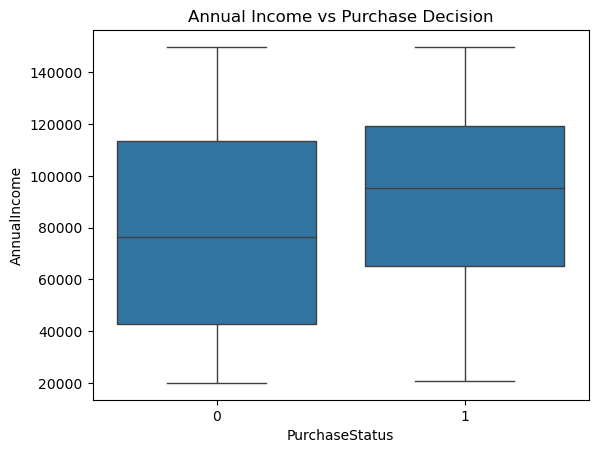

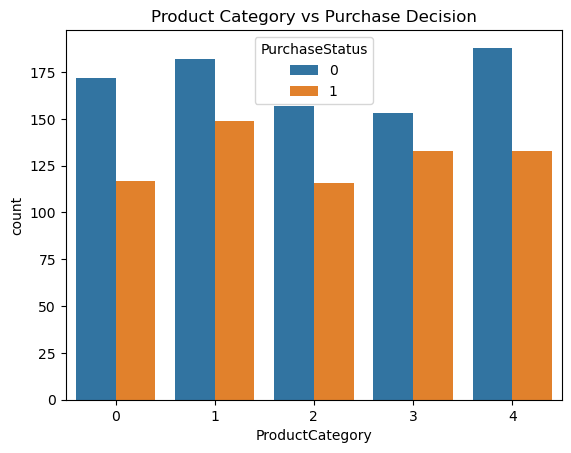

In [5]:
# (Higher grades task) Create at least 2 data visualizations of two features and justify the observation.
sns.boxplot(x='PurchaseStatus', y='AnnualIncome', data=data)
plt.title("Annual Income vs Purchase Decision")
plt.show()

sns.countplot(x='ProductCategory', hue='PurchaseStatus', data=data)
plt.title("Product Category vs Purchase Decision")
plt.show()

In [6]:
# Split the data into training dataset and test dataset with 80:20 ratio.
X = data.drop('PurchaseStatus', axis=1)
y = data['PurchaseStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Justify the observed patterns or relationships:

<font color='blue'> 
The boxplot shows that customers with higher annual income generally demonstrate a greater likelihood of making purchases. This suggests that customers with stronger financial capacity are more willing or able to purchase products.

The countplot indicates that purchase behavior varies across product categories. Certain product categories appear to attract more successful purchases than others, suggesting that customer interest and purchasing decisions may depend on the type of product offered.

#### Explain the chosen approach to handle missing values:

<font color='blue'> 
We chose median imputation for numerical features because it is robust against extreme outliers. For categorical features, we used the mode since it best represents the majority class without introducing bias.

### Part II: Model Building (6%)
Once the data preparation above is completed, build two supervised models using the training set. Each model should predict two classes: 0 (not purchased) and 1 (purchased).

In [7]:
# Train Model 1
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print("Naive Bayes Training Accuracy:", nb_model.score(X_train, y_train))

Naive Bayes Training Accuracy: 0.7858333333333334


In [8]:
# Train Model 2
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Training Accuracy:", rf_model.score(X_train, y_train))

Random Forest Training Accuracy: 1.0


### Part III: Model Deployment (2%)
Deploy the two supervised models built in Part II to predict the purchase behavior of all customers in the test set.

In [9]:
# Deploy Model 1
y_pred_nb = nb_model.predict(X_test)

print("Naïve Bayes Predictions (first 10):", y_pred_nb[:10])

Naïve Bayes Predictions (first 10): [1 0 0 0 1 0 1 0 0 0]


In [10]:
# Deploy Model 2
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Predictions (first 10):", y_pred_rf[:10])

Random Forest Predictions (first 10): [1 0 0 0 1 0 1 0 0 0]


### Part IV: Model Evaluation (7%)
<li> Evaluate the performance of the models. For each model, you must: (a) Build a confusion matrix; (b) Show the evaluation metrics: True Positives (TP), True Negatives (TN), False Positives (FP), False Negatives (FN), Recall, Precision, and Accuracy; (c) Use classification_report() function.
<li> Compare the performance of both models on both the training and test sets by constructing confusion matrices and compute all the evaluation metrics mentioned above for each set.


In [11]:
# Evaluate Model 1
cm_nb = confusion_matrix(y_test, y_pred_nb)
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

print("Naïve Bayes Test Confusion Matrix:\n", cm_nb)
print("Naïve Bayes Train Confusion Matrix:\n", confusion_matrix(y_train, nb_model.predict(X_train)))

print("Naïve Bayes Report:\n", classification_report(y_test, y_pred_nb))

print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("Naïve Bayes True Positive (TP):", tp_nb)
print("Naïve Bayes True Negative (TN):", tn_nb)
print("Naïve Bayes False Positive (FP):", fp_nb)
print("Naïve Bayes False Negative (FN):", fn_nb)

Naïve Bayes Test Confusion Matrix:
 [[156  16]
 [ 41  87]]
Naïve Bayes Train Confusion Matrix:
 [[575 105]
 [152 368]]
Naïve Bayes Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.85       172
           1       0.84      0.68      0.75       128

    accuracy                           0.81       300
   macro avg       0.82      0.79      0.80       300
weighted avg       0.81      0.81      0.81       300

Naïve Bayes Accuracy: 0.81
Naïve Bayes True Positive (TP): 87
Naïve Bayes True Negative (TN): 156
Naïve Bayes False Positive (FP): 16
Naïve Bayes False Negative (FN): 41


In [12]:
# Evaluate Model 2
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("Random Forest Test Confusion Matrix:\n", cm_rf)
print("Random Forest Train Confusion Matrix:\n", confusion_matrix(y_train, rf_model.predict(X_train)))

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest True Positive (TP):", tp_rf)
print("Random Forest True Negative (TN):", tn_rf)
print("Random Forest False Positive (FP):", fp_rf)
print("Random Forest False Negative (FN):", fn_rf)

Random Forest Test Confusion Matrix:
 [[171   1]
 [ 13 115]]
Random Forest Train Confusion Matrix:
 [[680   0]
 [  0 520]]
Random Forest Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       172
           1       0.99      0.90      0.94       128

    accuracy                           0.95       300
   macro avg       0.96      0.95      0.95       300
weighted avg       0.96      0.95      0.95       300

Random Forest Accuracy: 0.9533333333333334
Random Forest True Positive (TP): 115
Random Forest True Negative (TN): 171
Random Forest False Positive (FP): 1
Random Forest False Negative (FN): 13


In [13]:
# Compare performance of both models on both the training and the test sets
print("Naïve Bayes Training Accuracy:", nb_model.score(X_train, y_train))
print("Random Forest Training Accuracy:", rf_model.score(X_train, y_train))

print("Naïve Bayes Test Accuracy:", nb_model.score(X_test, y_test))
print("Random Forest Test Accuracy:", rf_model.score(X_test, y_test))

Naïve Bayes Training Accuracy: 0.7858333333333334
Random Forest Training Accuracy: 1.0
Naïve Bayes Test Accuracy: 0.81
Random Forest Test Accuracy: 0.9533333333333334


### Requirements for higher grades than PASS.
<li> Model Performance: Discuss why models generally perform better on the training set compared to the test set. Provide insights into the factors that contribute to this discrepancy.
<li> Overfitting and Underfitting: Define and describe the problems of overfitting and underfitting. Discuss multiple strategies to alleviate these issues.

#### Why models perform better on the training set than on the test set:

<font color='blue'> 
Models generally perform better on the training set because the models learn directly from that data during the training process. As a result, the models become highly familiar with the patterns, relationships, and characteristics within the training dataset. However, the test set contains unseen data that the models have not encountered before. Therefore, the performance on the test set is usually lower because the models must generalize their learned knowledge to new data rather than relying on memorization.

#### Overfitting and underfitting problems and ways to alleviate them:

<font color='blue'> 
Overfitting occurs when a model learns the training data too closely, including noise and unnecessary details, resulting in poor performance on unseen data. Common methods to reduce overfitting include cross-validation, reducing model complexity, regularization, pruning decision trees, and increasing the amount of training data.

Underfitting occurs when a model is too simple to capture the underlying patterns in the dataset, leading to poor performance on both training and test sets. Underfitting can be alleviated by using more complex models, selecting more relevant features, tuning hyperparameters, and improving data preprocessing techniques.

## References

<font color='blue'>

## Group Member Contributions
<li> Group Member 1: <font color='blue'>33.33%</font></li>
<li> Group Member 2: <font color='blue'>33.33%</font></li>
<li> Group Member 3: <font color='blue'>33.33%</font></li>